In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import webbrowser
import os

nltk.download('vader_lexicon')

apps_df=pd.read_csv('Play Store Data.csv')
reviews_df=pd.read_csv('User Reviews.csv')

#Step 2 : Data Cleaning
apps_df = apps_df.dropna(subset=['Rating'])
for column in apps_df.columns :
    apps_df[column].fillna(apps_df[column].mode()[0],inplace=True)
apps_df.drop_duplicates(inplace=True)
apps_df=apps_df=apps_df[apps_df['Rating']<=5]
reviews_df.dropna(subset=['Translated_Review'],inplace=True)

#Convert the Installs columns to numeric by removing commas and +
apps_df['Installs']=apps_df['Installs'].str.replace(',','').str.replace('+','').astype(int)

#Convert Price column to numeric after removing $
apps_df['Price']=apps_df['Price'].str.replace('$','').astype(float)

merged_df=pd.merge(apps_df,reviews_df,on='App',how='inner')

def convert_size(size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024
    else:
        return np.nan
apps_df['Size']=apps_df['Size'].apply(convert_size)

#Lograrithmic
apps_df['Log_Installs']=np.log(apps_df['Installs'])

apps_df['Reviews']=apps_df['Reviews'].astype(int)

apps_df['Log_Reviews']=np.log(apps_df['Reviews'])

def rating_group(rating):
    if rating >= 4:
        return 'Top rated app'
    elif rating >=3:
        return 'Above average'
    elif rating >=2:
        return 'Average'
    else:
        return 'Below Average'
apps_df['Rating_Group']=apps_df['Rating'].apply(rating_group)

#Revenue column
apps_df['Revenue']=apps_df['Price']*apps_df['Installs']

sia = SentimentIntensityAnalyzer()

#Polarity Scores in SIA
#Positive, Negative, Neutral and Compound: -1 - Very negative ; +1 - Very positive

review = "This app is amazing! I love the new features."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

review = "This app is very bad! I hate the new features."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

review = "This app is okay."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

reviews_df['Sentiment_Score']=reviews_df['Translated_Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

apps_df['Last Updated']=pd.to_datetime(apps_df['Last Updated'],errors='coerce')

apps_df['Year']=apps_df['Last Updated'].dt.year

html_files_path="./"
if not os.path.exists(html_files_path):
    os.makedirs(html_files_path)

plot_containers=""

# Save each Plotly figure to an HTML file
def save_plot_as_html(fig, filename, insight):
    global plot_containers
    filepath = os.path.join(html_files_path, filename)
    html_content = pio.to_html(fig, full_html=False, include_plotlyjs='inline')
    # Append the plot and its insight to plot_containers
    plot_containers += f"""
    <div class="plot-container" id="{filename}" onclick="openPlot('{filename}')">
        <div class="plot">{html_content}</div>
        <div class="insights">{insight}</div>
    </div>
    """
    fig.write_html(filepath, full_html=False, include_plotlyjs='inline')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jirfa\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\jirfa\AppData\Local\Temp\ipykernel_12316\701767692.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps_df[column].fillna(apps_df[column].mode()[0],inplace=True)


{'neg': 0.0, 'neu': 0.42, 'pos': 0.58, 'compound': 0.8516}
{'neg': 0.535, 'neu': 0.465, 'pos': 0.0, 'compound': -0.8427}
{'neg': 0.0, 'neu': 0.612, 'pos': 0.388, 'compound': 0.2263}


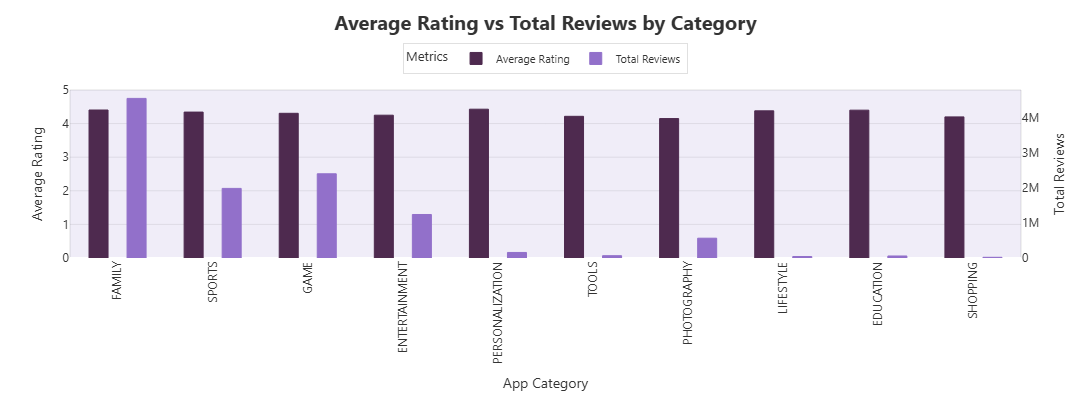

In [78]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pytz
from datetime import datetime, time

# -------------------------
# TIME CHECK FUNCTION
# -------------------------
def is_time_allowed():
    ist = pytz.timezone("Asia/Kolkata")
    now = datetime.now(ist).time()
    return time(15,0) <= now <= time(17,0)

# -------------------------
# LOAD DATA
# -------------------------
apps_df = pd.read_csv("Play Store Data.csv")

apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'], errors='coerce')
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

apps_df['Installs'] = (
    apps_df['Installs']
    .astype(str)
    .str.replace(r'\D','', regex=True)
    .replace('', '0')
    .astype(float)
)

apps_df['Size'] = (
    apps_df['Size']
    .astype(str)
    .replace('Varies with device', None)
    .str.replace('M','', regex=False)
    .str.replace('k','', regex=False)
)

apps_df['Size'] = pd.to_numeric(apps_df['Size'], errors='coerce')

# -------------------------
# FILTER DATA
# -------------------------
task1_df = apps_df[
    (apps_df['Rating'] >= 4.0) &
    (apps_df['Size'] >= 10) &
    (apps_df['Last Updated'].dt.month == 1)
]

# -------------------------
# CATEGORY SUMMARY
# -------------------------
category_summary = (
    task1_df
    .groupby('Category')
    .agg(
        avg_rating=('Rating','mean'),
        total_reviews=('Reviews','sum'),
        total_installs=('Installs','sum')
    )
    .sort_values('total_installs',ascending=False)
    .head(10)
    .reset_index()
)

category_summary['Category'] = (
    category_summary['Category']
    .str.replace('_AND_', '<br>')
    .str.replace('_','<br>')
)

# -------------------------
# SHOW CHART OR LOCK SCREEN
# -------------------------
if is_time_allowed():

    fig = go.Figure()

    avg_rating_color = "#4E2A4F"
    total_reviews_color = "#9270CA"

    fig.add_bar(
        x=category_summary['Category'],
        y=category_summary['avg_rating'],
        name="Average Rating",
        marker=dict(color=avg_rating_color,line=dict(color=avg_rating_color,width=1)),
        width=0.20,
        offsetgroup=1
    )

    fig.add_bar(
        x=category_summary['Category'],
        y=category_summary['total_reviews'],
        name="Total Reviews",
        yaxis="y2",
        marker=dict(color=total_reviews_color,line=dict(color=total_reviews_color,width=1)),
        width=0.20,
        offsetgroup=2
    )

    fig.update_layout(

        title=dict(
            text="<b>Average Rating vs Total Reviews by Category</b>",
            x=0.5,
            y=0.96,
            xanchor="center",
            font=dict(size=20,family="Segoe UI")
        ),

        font=dict(family="Segoe UI",color="#333"),

        xaxis=dict(
            title="App Category",
            tickangle=-90,
            showgrid=False
        ),

        yaxis=dict(
            title="Average Rating",
            range=[0,5],
            gridcolor="rgba(0,0,0,0.08)"
        ),

        yaxis2=dict(
            title="Total Reviews",
            overlaying="y",
            side="right",
            showgrid=False
        ),

        barmode="group",

        paper_bgcolor="white",
        plot_bgcolor="rgba(146,112,202,0.08)",

        legend=dict(
            title="Metrics",
            orientation="h",
            y=1.28,
            x=0.5,
            xanchor="center",
            bordercolor="rgba(0,0,0,0.12)",
            borderwidth=1,
            font=dict(size=11)
        ),

        margin=dict(t=90,l=70,r=70,b=120),

        height=400,

        shapes=[
            dict(
                type="rect",
                xref="paper",
                yref="paper",
                x0=0,
                y0=0,
                x1=1,
                y1=1,
                line=dict(color="rgba(0,0,0,0.12)",width=1),
                fillcolor="rgba(146,112,202,0.05)",
                layer="below"
            )
        ]
    )

    fig.show()

    pio.write_html(fig,"task1.html",auto_open=False)

else:

    with open("task1.html","w",encoding="utf-8") as f:
        f.write("""
<html>
<head>
<style>
body{
margin:0;
height:100vh;
display:flex;
align-items:center;
justify-content:center;
background:white;
font-family:Segoe UI;
}
.card{
padding:40px 60px;
border-radius:20px;
background:rgba(146,112,202,0.15);
color:#222;
text-align:center;
}
</style>
</head>
<body>
<div class="card">
<h2>⏰ Visualization Locked</h2>
<p>Chart available only between</p>
<p><b>3 PM – 5 PM IST</b></p>
</div>
</body>
</html>
""")

    print("Task 1 chart available only between 3 PM – 5 PM IST")

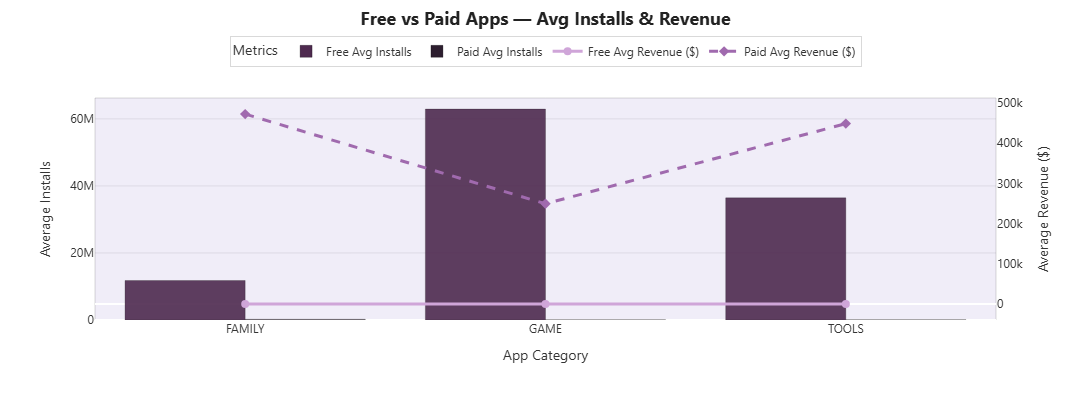

In [116]:
import pandas as pd
import pytz
from datetime import datetime, time
import plotly.graph_objects as go
import plotly.io as pio

# -------------------------
# LOAD DATA
# -------------------------
apps_df = pd.read_csv("Play Store Data.csv")

# Clean Installs
apps_df['Installs_Num'] = (
    apps_df['Installs']
    .astype(str)
    .str.replace(r'\D','',regex=True)
    .replace('', '0')
    .astype(float)
)

# Clean Price
apps_df['Price_Num'] = (
    apps_df['Price']
    .astype(str)
    .str.replace(r'[^0-9.]','',regex=True)
    .replace('', '0')
    .astype(float)
)

# Revenue
apps_df['Revenue'] = apps_df['Price_Num'] * apps_df['Installs_Num']

# Convert Size
def convert_size(size):

    size=str(size)

    if "M" in size:
        return float(size.replace("M",""))

    if "k" in size:
        return float(size.replace("k",""))/1024

    return None

apps_df['Size_MB']=apps_df['Size'].apply(convert_size)

# Android Version
def clean_android(v):

    try:
        v=str(v)

        if "Varies" in v:
            return None

        return float(v[:3])

    except:
        return None

apps_df['Android_Ver']=apps_df['Android Ver'].apply(clean_android)

# App Name Length
apps_df['Name_Len']=apps_df['App'].astype(str).str.len()


# -------------------------
# TIME LOCK
# -------------------------
def is_time_allowed():

    ist=pytz.timezone("Asia/Kolkata")
    now=datetime.now(ist).time()

    return time(13,0) <= now <= time(14,0)


# -------------------------
# FILTER DATA
# -------------------------
task2_df = apps_df[
    (apps_df['Android_Ver']>4.0) &
    (apps_df['Size_MB']>15) &
    (apps_df['Content Rating']=="Everyone") &
    (apps_df['Name_Len']<=30) &
    ~((apps_df['Installs_Num']<10000) & (apps_df['Revenue']<10000))
]

# -------------------------
# TOP 3 CATEGORIES
# -------------------------
top_categories = (
    task2_df
    .groupby('Category')['Installs_Num']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

task2_df = task2_df[task2_df['Category'].isin(top_categories)]

# -------------------------
# GROUP DATA
# -------------------------
summary = (
    task2_df
    .groupby(['Category','Type'])
    .agg(
        avg_installs=('Installs_Num','mean'),
        avg_revenue=('Revenue','mean')
    )
    .reset_index()
)

# -------------------------
# CREATE CHART
# -------------------------
if True:

    fig = go.Figure()

    # Avg Installs Bars
    for t in ['Free','Paid']:

        subset = summary[summary['Type']==t]

        fig.add_bar(
            x=subset['Category'],
            y=subset['avg_installs'],
            name=f"{t} Avg Installs",
            marker=dict(
                color="#4E2A4F" if t=="Free" else "#2D1E2F",
                opacity=0.9 if t=="Free" else 0.75,
                line=dict(color="rgba(0,0,0,0.25)",width=1)
            ),
            offsetgroup=t
        )

    # Avg Revenue Lines
    for t in ['Free','Paid']:

        subset = summary[summary['Type']==t]

        fig.add_scatter(
            x=subset['Category'],
            y=subset['avg_revenue'],
            mode="lines+markers",
            name=f"{t} Avg Revenue ($)",
            yaxis="y2",
            line=dict(
                color="#CFA5D8" if t=="Free" else "#A06AAE",
                width=3,
                dash="solid" if t=="Free" else "dash"
            ),
            marker=dict(
                size=8,
                symbol="circle" if t=="Free" else "diamond"
            )
        )

# -------------------------
# LAYOUT (WHITE STYLE)
# -------------------------
    fig.update_layout(

        title=dict(
            text="<b>Free vs Paid Apps — Avg Installs & Revenue</b>",
            x=0.5,
            y=0.97,
            xanchor="center",
            font=dict(size=18,color="#222",family="Segoe UI")
        ),

        font=dict(
            family="Segoe UI",
            color="#333"
        ),

        xaxis=dict(
            title="App Category",
            showgrid=False
        ),

        yaxis=dict(
            title="Average Installs",
            gridcolor="rgba(0,0,0,0.08)"
        ),

        yaxis2=dict(
            title="Average Revenue ($)",
            overlaying="y",
            side="right",
            showgrid=False
        ),

        barmode="group",

        paper_bgcolor="white",

        plot_bgcolor="rgba(146,112,202,0.08)",

        legend=dict(
            title="Metrics",
            orientation="h",
            y=1.28,
            x=0.5,
            xanchor="center",
            bgcolor="rgba(0,0,0,0)",
            bordercolor="rgba(0,0,0,0.15)",
            borderwidth=1
        ),

        margin=dict(
            t=98,
            l=95,
            r=95,
            b=80
        ),

        height=400,

        shapes=[
            dict(
                type="rect",
                xref="paper",
                yref="paper",
                x0=0,
                y0=0,
                x1=1,
                y1=1,
                line=dict(color="rgba(0,0,0,0.15)", width=1),
                fillcolor="rgba(146,112,202,0.05)",
                layer="below"
            )
        ]
    )

    fig.show()
    pio.write_html(fig,"task2.html",auto_open=False)

# -------------------------
# LOCK SCREEN
# -------------------------
else:

    with open("task2.html","w",encoding="utf-8") as f:
        f.write("""
<html>
<head>
<style>
body{
margin:0;
height:100vh;
display:flex;
align-items:center;
justify-content:center;
background:white;
font-family:Segoe UI;
}

.card{
padding:40px 60px;
border-radius:20px;
background:rgba(146,112,202,0.15);
color:#222;
text-align:center;
}
</style>
</head>

<body>

<div class="card">

<h2>⏰ Visualization Locked</h2>
<p>Chart available only between</p>
<p><b>1 PM – 2 PM IST</b></p>

</div>

</body>
</html>
""")

    print("Task 2 chart available only between 1 PM – 2 PM IST")

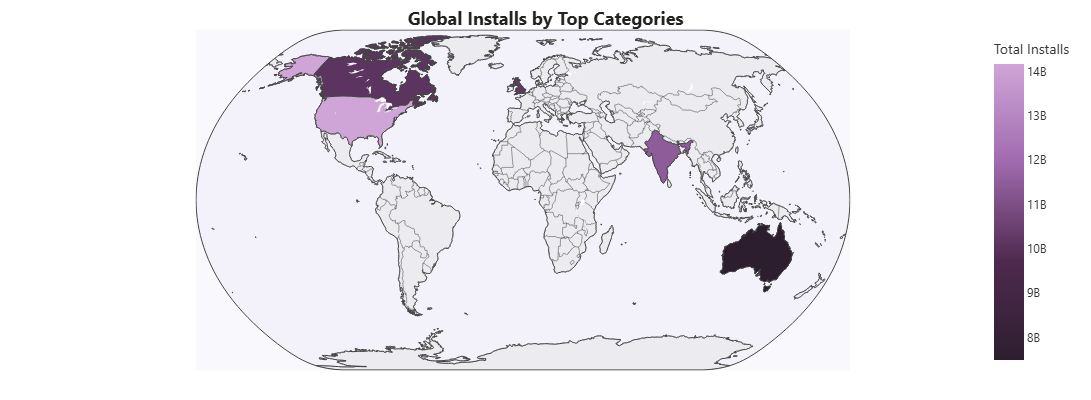

In [130]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
from datetime import datetime, time
import pytz

# TIME CHECK (6 PM – 8 PM IST)
def is_ist_time_allowed():
    ist = pytz.timezone("Asia/Kolkata")
    now = datetime.now(ist).time()
    return time(18,0) <= now <= time(20,0)

# LOAD DATA
apps_df = pd.read_csv("Play Store Data.csv")

# CLEAN INSTALLS
apps_df["Installs_Num"] = (
    apps_df["Installs"]
    .astype(str)
    .str.replace(r"\D","",regex=True)
)

apps_df["Installs_Num"] = pd.to_numeric(
    apps_df["Installs_Num"], errors="coerce"
)

# FILTER CATEGORY
apps_df = apps_df[
    ~apps_df["Category"].str.startswith(("A","C","G","S"),na=False)
]

# TOP 5 CATEGORIES
top_categories = (
    apps_df.groupby("Category")["Installs_Num"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

apps_df = apps_df[apps_df["Category"].isin(top_categories)]

# COUNTRY MAPPING
country_mapping = {
    top_categories[0]:"USA",
    top_categories[1]:"IND",
    top_categories[2]:"GBR",
    top_categories[3]:"CAN",
    top_categories[4]:"AUS"
}

apps_df["Country"] = apps_df["Category"].map(country_mapping)

# AGGREGATE
map_df = (
    apps_df.groupby(["Country","Category"])
    .agg(total_installs=("Installs_Num","sum"))
    .reset_index()
)

map_df["Highlight"] = map_df["total_installs"] > 1000000

if True:

    fig = px.choropleth(
        map_df,
        locations="Country",
        locationmode="ISO-3",
        color="total_installs",
        hover_name="Category",
        hover_data=["total_installs","Highlight"],
        labels={"total_installs":"Total Installs"},
        color_continuous_scale=[
            "#2D1E2F",
            "#4E2A4F",
            "#A06AAE",
            "#CFA5D8"
        ]
    )

    fig.update_layout(

        title=dict(
            text="<b>Global Installs by Top Categories</b>",
            x=0.5,
            y=0.97,
            xanchor="center",
            font=dict(
                size=18,
                color="#222",
                family="Segoe UI"
            )
        ),

        font=dict(
            family="Segoe UI",
            color="#333"
        ),

        paper_bgcolor="white",

        plot_bgcolor="rgba(146,112,202,0.08)",

        margin=dict(
            t=30,
            l=80,
            r=80,
            b=30
        ),

        height=400,

        coloraxis_colorbar=dict(
            title="Total Installs"
        ),

        geo=dict(
            bgcolor="rgba(146,112,202,0.05)",
            showland=True,
            landcolor="rgba(0,0,0,0.05)",
            showcountries=True,
            countrycolor="rgba(0,0,0,0.2)",
            showocean=True,
            oceancolor="rgba(146,112,202,0.05)",
            projection_type="natural earth"
        )
    )



    fig.show()

    pio.write_html(fig,"task3.html",auto_open=False)

else:

    with open("task3.html","w",encoding="utf-8") as f:
        f.write("""
<html>
<head>
<style>
body{
margin:0;
height:100vh;
display:flex;
align-items:center;
justify-content:center;
background:white;
font-family:Segoe UI;
}
.card{
padding:40px 60px;
border-radius:20px;
background:rgba(146,112,202,0.15);
color:#222;
text-align:center;
}
</style>
</head>
<body>
<div class="card">
<h2>⏰ Task 3 Locked</h2>
<p>Map visible only between</p>
<p><b>6 PM – 8 PM IST</b></p>
</div>
</body>
</html>
""")

    print("Task 3 visible only between 6 PM – 8 PM IST")

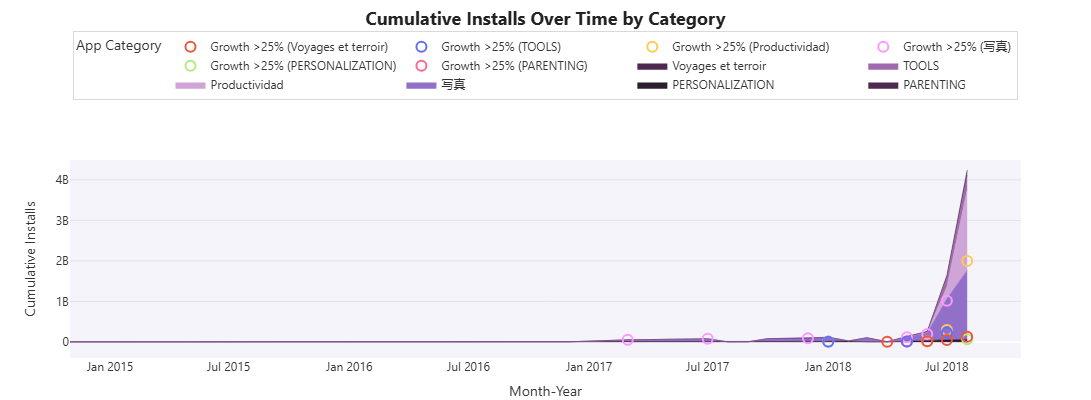

In [134]:
import pandas as pd
import pytz
from datetime import datetime, timedelta, timezone
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("Play Store Data.csv")

# --- Data Cleaning ---
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Installs'] = df['Installs'].astype(str).str.replace(r'\D', '', regex=True).replace('', '0').astype(int)
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

def clean_size(size):
    size_str = str(size)
    if 'M' in size_str: return float(size_str.replace('M', ''))
    if 'k' in size_str: return float(size_str.replace('k', '')) / 1024
    return 0

df['Size_MB'] = df['Size'].apply(clean_size)

# --- Filtering for Task 4 ---
mask = (
    (df['Rating'] >= 4.2) &
    (~df['App'].str.contains(r'\d', na=False)) &
    (df['Category'].str.startswith(('T','P'), na=False)) &
    (df['Reviews'] > 1000) &
    (df['Size_MB'] >= 20) & (df['Size_MB'] <= 80)
)

df_filtered = df[mask].copy()

# --- Time Lock 4-6 PM IST ---
ist = pytz.timezone("Asia/Kolkata")
now_ist = datetime.now(ist)

if True:

    # --- Prepare Time Series ---
    df_filtered['Month_Year'] = df_filtered['Last Updated'].dt.to_period('M').dt.to_timestamp()

    ts_df = df_filtered.groupby(['Category','Month_Year'])['Installs'].sum().reset_index()

    ts_df = ts_df.sort_values(['Category','Month_Year'])

    ts_df['Cumulative_Installs'] = ts_df.groupby('Category')['Installs'].cumsum()

    ts_df['MoM_Growth'] = ts_df.groupby('Category')['Installs'].pct_change()

    translations = {
        'TRAVEL_AND_LOCAL': 'Voyages et terroir',
        'PRODUCTIVITY': 'Productividad',
        'PHOTOGRAPHY': '写真'
    }

    ts_df['Category_Display'] = ts_df['Category'].map(lambda x: translations.get(x, x))

    # -------------------------
    # CREATE CHART
    # -------------------------
    fig = go.Figure()

    color_seq = ["#4E2A4F", "#2D1E2F", "#9270CA", "#CFA5D8", "#A06AAE"]

    for i, cat in enumerate(ts_df['Category_Display'].unique()):

        cat_data = ts_df[ts_df['Category_Display'] == cat]

        fig.add_trace(go.Scatter(
            x=cat_data['Month_Year'],
            y=cat_data['Cumulative_Installs'],
            mode='lines',
            name=cat,
            stackgroup='one',
            line=dict(width=0.5, color=color_seq[i % len(color_seq)]),
            fillcolor=color_seq[i % len(color_seq)],
            opacity=0.7,
            hovertemplate="%{x|%b %Y}<br>%{y:,.0f} Installs<extra></extra>"
        ))

    # Highlight Growth >25%
    high_growth = ts_df[ts_df['MoM_Growth'] > 0.25]

    for cat in high_growth['Category_Display'].unique():

        hg_data = high_growth[high_growth['Category_Display']==cat]

        fig.add_trace(go.Scatter(
            x=hg_data['Month_Year'],
            y=hg_data['Cumulative_Installs'],
            mode='markers',
            marker=dict(size=10, symbol='circle-open', line=dict(width=2, color="#FF4B4B")),
            name=f'Growth >25% ({cat})',
            hovertemplate="%{text}<extra></extra>",
            text=[f"{cat}: {g:.1%} MoM Increase" for g in hg_data['MoM_Growth']]
        ))

    # -------------------------
    # LAYOUT (WHITE DASHBOARD STYLE)
    # -------------------------
    fig.update_layout(

        title=dict(
            text="<b>Cumulative Installs Over Time by Category</b>",
            x=0.5,
            y=0.97,
            font=dict(size=18, color="#222", family="Segoe UI")
        ),

        font=dict(
            family="Segoe UI",
            color="#333"
        ),

        xaxis=dict(
            title="Month-Year",
            showgrid=False
        ),

        yaxis=dict(
            title="Cumulative Installs",
            gridcolor="rgba(0,0,0,0.08)"
        ),

        barmode='stack',

        paper_bgcolor="white",

        plot_bgcolor="rgba(146,112,202,0.08)",

        legend=dict(
            title="App Category",
            orientation="h",
            y=1.65,
            x=0.5,
            xanchor="center",
            bgcolor="rgba(0,0,0,0)",
            bordercolor="rgba(0,0,0,0.15)",
            borderwidth=1
        ),

        margin=dict(
            t=160,
            l=70,
            r=70,
            b=2
        ),

        height=400
    )

    fig.show()

    pio.write_html(fig,"task4.html",auto_open=False)

else:

    with open("task4.html","w",encoding="utf-8") as f:

        f.write("""
<html>
<head>
<style>
body{
margin:0;
height:100vh;
display:flex;
align-items:center;
justify-content:center;
background:white;
font-family:Segoe UI;
}

.card{
padding:40px 60px;
border-radius:20px;
background:rgba(146,112,202,0.15);
color:#222;
text-align:center;
}
</style>
</head>

<body>

<div class="card">

<h2>⏰ Task 4 Locked</h2>

<p>Visible only between</p>

<p><b>4 PM – 6 PM IST</b></p>

</div>

</body>
</html>
""")

    print("Task 4 chart available only between 4 PM – 6 PM IST")

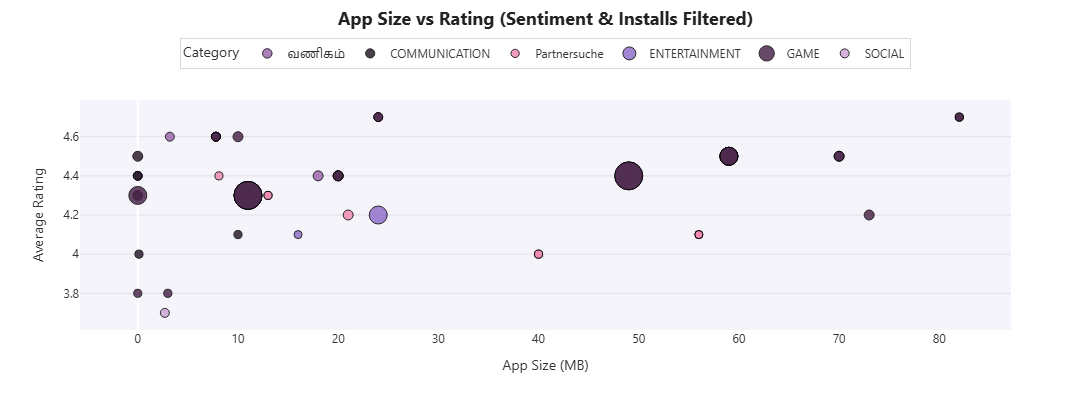

In [122]:
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime, timedelta, timezone
import plotly.io as pio

# -------------------------
# LOAD DATA
# -------------------------
apps_df = pd.read_csv("Play Store Data.csv")
reviews_df = pd.read_csv("User Reviews.csv")

# -------------------------
# SENTIMENT AVERAGE
# -------------------------
sentiment_avg = reviews_df.groupby('App')['Sentiment_Subjectivity'].mean().reset_index()
df = pd.merge(apps_df, sentiment_avg, on='App')

# -------------------------
# CLEAN DATA
# -------------------------
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Installs_Num'] = pd.to_numeric(df['Installs'].astype(str).str.replace(r'\D','',regex=True), errors='coerce').fillna(0)

def clean_size(size):
    size = str(size)
    if 'M' in size: return float(size.replace('M',''))
    if 'k' in size: return float(size.replace('k',''))/1024
    return 0

df['Size_MB'] = df['Size'].apply(clean_size)

# -------------------------
# TIME LOCK 5-7 PM IST
# -------------------------
now_ist = datetime.now(timezone(timedelta(hours=5, minutes=30)))

if True:

    # -------------------------
    # FILTER DATA
    # -------------------------
    target_cats = ['GAME','BEAUTY','BUSINESS','COMICS','COMMUNICATION','DATING','ENTERTAINMENT','SOCIAL','EVENTS']

    mask = (
        df['Category'].str.upper().isin(target_cats) &
        (df['Rating'] > 3.5) &
        (df['Reviews'] > 500) &
        (~df['App'].str.contains('S', case=False, na=False)) &
        (df['Sentiment_Subjectivity'] > 0.5) &
        (df['Installs_Num'] > 50000)
    )

    filtered_df = df[mask].copy()

    # -------------------------
    # TRANSLATIONS
    # -------------------------
    translation_map = {
        'BEAUTY': 'सुंदरता',
        'BUSINESS': 'வணிகம்',
        'DATING': 'Partnersuche'
    }

    filtered_df['Category_Display'] = filtered_df['Category'].str.upper().map(lambda x: translation_map.get(x, x))

    # -------------------------
    # COLOR MAP
    # -------------------------
    color_map = {
        'GAME': '#4E2A4F',
        'COMMUNICATION': '#2D1E2F',
        'ENTERTAINMENT': '#9270CA',
        'SOCIAL': '#CFA5D8',
        'வணிகம்': '#A06AAE',
        'सुंदरता': '#c39bd3',
        'Partnersuche': '#F08BB4',
        'COMICS': '#17BECF',
        'EVENTS': '#8FD3C7'
    }

    # -------------------------
    # SCALE BUBBLE SIZE
    # -------------------------
    min_size, max_size = 8, 28

    filtered_df['Bubble_Size'] = (
        (filtered_df['Installs_Num'] - filtered_df['Installs_Num'].min()) /
        (filtered_df['Installs_Num'].max() - filtered_df['Installs_Num'].min()) *
        (max_size - min_size) + min_size
    )

    # -------------------------
    # CREATE FIGURE
    # -------------------------
    fig = go.Figure()

    for cat in filtered_df['Category_Display'].unique():

        cat_data = filtered_df[filtered_df['Category_Display'] == cat]

        fig.add_trace(go.Scatter(
            x=cat_data['Size_MB'],
            y=cat_data['Rating'],
            mode='markers',
            marker=dict(
                size=cat_data['Bubble_Size'],
                color=color_map.get(cat, '#AAAAAA'),
                line=dict(width=1, color='black'),
                opacity=0.85
            ),
            name=cat,
            hovertemplate=(
                "<b>%{hovertext}</b><br>" +
                "Size: %{x:.2f} MB<br>" +
                "Rating: %{y:.2f}<br>" +
                "Installs: %{customdata:,}<br>" +
                "Sentiment: %{text:.2f}<extra></extra>"
            ),
            hovertext=cat_data['App'],
            customdata=cat_data['Installs_Num'],
            text=cat_data['Sentiment_Subjectivity']
        ))

    # -------------------------
    # LAYOUT (WHITE DASHBOARD STYLE)
    # -------------------------
    fig.update_layout(

        title=dict(
            text="<b>App Size vs Rating (Sentiment & Installs Filtered)</b>",
            x=0.5,
            y=0.97,
            font=dict(size=18, color="#222", family="Segoe UI")
        ),

        font=dict(
            family="Segoe UI",
            color="#333"
        ),

        xaxis=dict(
            title="App Size (MB)",
            showgrid=False
        ),

        yaxis=dict(
            title="Average Rating",
            gridcolor="rgba(0,0,0,0.08)"
        ),

        paper_bgcolor="white",

        plot_bgcolor="rgba(146,112,202,0.08)",

        legend=dict(
            title="Category",
            orientation="h",
            y=1.27,
            x=0.5,
            xanchor="center",
            bgcolor="rgba(0,0,0,0)",
            bordercolor="rgba(0,0,0,0.15)",
            borderwidth=1
        ),

        margin=dict(
            t=100,
            l=80,
            r=80,
            b=70
        ),

        height=400
    )

    fig.show()

    pio.write_html(fig, "task5.html", auto_open=False)

else:

    # -------------------------
    # LOCK SCREEN
    # -------------------------
    with open("task5.html","w",encoding="utf-8") as f:

        f.write("""
<html>
<head>
<style>
body{
margin:0;
height:100vh;
display:flex;
align-items:center;
justify-content:center;
background:white;
font-family:Segoe UI;
}

.card{
padding:40px 60px;
border-radius:20px;
background:rgba(146,112,202,0.15);
color:#222;
text-align:center;
}
</style>
</head>

<body>

<div class="card">

<h2>⏰ Task 5 Locked</h2>

<p>Visible only between</p>

<p><b>5 PM – 7 PM IST</b></p>

</div>

</body>
</html>
""")

    print(f"Task 5 chart available only between 5 PM – 7 PM IST. Current IST: {now_ist.strftime('%H:%M')}")

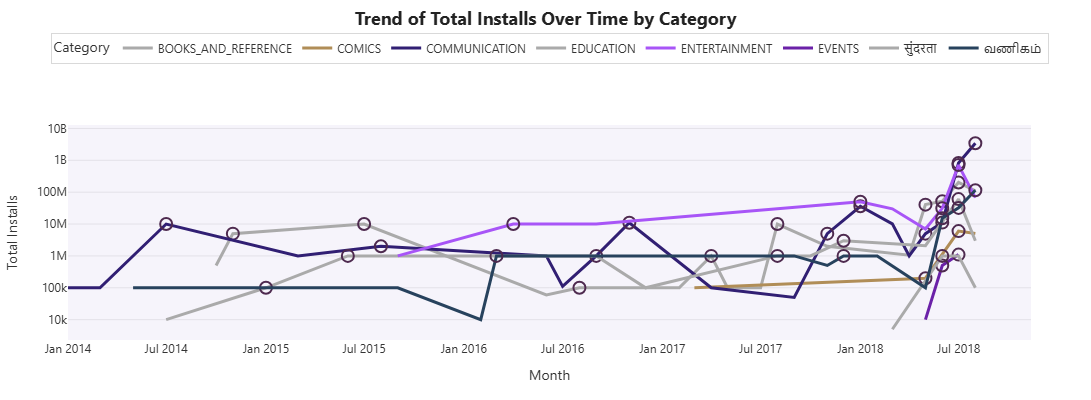

In [236]:
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime, timedelta, timezone
import plotly.io as pio

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("Play Store Data.csv")

# -------------------------
# CLEAN DATA
# -------------------------
df["Installs"] = pd.to_numeric(
    df["Installs"].astype(str).str.replace(r"\D", "", regex=True),
    errors="coerce"
).fillna(0)

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce").fillna(0)

df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

# -------------------------
# FILTER DATA
# -------------------------
mask = (
    (df["Category"].str.startswith(("E","C","B"), na=False)) &
    (~df["App"].str.startswith(("X","Y","Z","x","y","z"), na=False)) &
    (~df["App"].str.contains("S", case=False, na=False)) &
    (df["Reviews"] > 500)
)

df = df[mask].copy()

# -------------------------
# TRANSLATE CATEGORY
# -------------------------
translation_map = {
    "BEAUTY": "सुंदरता",
    "BUSINESS": "வணிகம்",
    "DATING": "Partnersuche"
}

df["Category_Display"] = df["Category"].replace(translation_map)

# -------------------------
# TIME SERIES
# -------------------------
df["Month"] = df["Last Updated"].dt.to_period("M").dt.to_timestamp()

ts = (
    df.groupby(["Category_Display","Month"])["Installs"]
    .sum()
    .reset_index()
    .sort_values(["Category_Display","Month"])
)

ts["MoM_Growth"] = ts.groupby("Category_Display")["Installs"].pct_change()

# -------------------------
# COLOR MAP
# -------------------------
color_map = {
    "COMICS": "#B08D57",
    "ENTERTAINMENT": "#A855F7",
    "COMMUNICATION": "#311F73",
    "வணிகம்": "#27425D",
    "EVENTS": "#6B21A8",
    "BEAUTY": "#4CA1AF",
    "Partnersuche": "#D8B4FE"
}

# -------------------------
# CREATE FIGURE
# -------------------------
fig = go.Figure()

for cat in ts["Category_Display"].unique():

    cat_df = ts[ts["Category_Display"] == cat]

    fig.add_trace(go.Scatter(
        x=cat_df["Month"],
        y=cat_df["Installs"],
        mode="lines",
        name=cat,
        line=dict(width=3, color=color_map.get(cat, "#AAAAAA")),
        hovertemplate="<b>%{text}</b><br>%{x|%b %Y}<br>Installs: %{y:,}<extra></extra>",
        text=[cat]*len(cat_df)
    ))

    growth_df = cat_df[cat_df["MoM_Growth"] > 0.20]

    if not growth_df.empty:

        fig.add_trace(go.Scatter(
            x=growth_df["Month"],
            y=growth_df["Installs"],
            mode="markers",
            marker=dict(
                size=12,
                color="#4E2A4F",
                symbol="circle-open",
                line=dict(width=2)
            ),
            name=f"{cat} >20% Growth",
            hovertemplate="%{text}: %{y:,} installs<br>Growth: %{customdata:.1%}<extra></extra>",
            text=[cat]*len(growth_df),
            customdata=growth_df["MoM_Growth"],
            showlegend=False
        ))

        for i, row in growth_df.iterrows():

            prev_row = cat_df[cat_df["Month"] < row["Month"]].tail(1)

            if not prev_row.empty:

                fig.add_vrect(
                    x0=prev_row["Month"].values[0],
                    x1=row["Month"],
                    fillcolor="rgba(255,0,0,0.25)",
                    layer="below",
                    line_width=0
                )

# -------------------------
# LAYOUT (WHITE DASHBOARD STYLE)
# -------------------------
fig.update_layout(

    title=dict(
        text="<b>Trend of Total Installs Over Time by Category</b>",
        x=0.5,
        y=0.97,
        font=dict(size=18, color="#222", family="Segoe UI")
    ),

    font=dict(
        family="Segoe UI",
        color="#333"
    ),

    paper_bgcolor="white",

    plot_bgcolor="rgba(146,112,202,0.08)",

    xaxis=dict(
        title="Month",
        showgrid=False,
        tickfont=dict(color="#333")
    ),

    yaxis=dict(
        title="Total Installs",
        type="log",
        gridcolor="rgba(0,0,0,0.08)",
        dtick=1,
        tickfont=dict(color="#333")
    ),

    hovermode="x unified",

    legend=dict(
        title="Category",
        orientation="h",
        y=1.43,
        x=0.5,
        xanchor="center",
        bgcolor="rgba(0,0,0,0)",
        bordercolor="rgba(0,0,0,0.15)",
        borderwidth=1
    ),

    margin=dict(
        t=125,
        l=60,
        r=60,
        b=60
    ),
    
    height=400
)

# -------------------------
# SHOW AND SAVE
# -------------------------
fig.show()

pio.write_html(fig, "task6.html", auto_open=False)

fig6 = fig

In [255]:
import os, webbrowser

dashboard_html = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Google Play Store Reviews Analytics</title>

<style>

body{
    margin:0;
    font-family:"Segoe UI", Arial, sans-serif;
    background: linear-gradient(135deg,#2D1E2F,#4E2A4F);
    color:white;
}

/* HEADER */
.header{
    position:fixed;
    justify-content:space-between;
    top:0;
    left:0;
    width:100%;
    height:70px;
    z-index:1000;
    background: linear-gradient(90deg,#2D1E2F,#4E2A4F);
    box-shadow:0 6px 20px rgba(0,0,0,0.6);
}

.header-inner{
    max-width:1400px;
    margin:0 auto;
    height:100%;
    display:flex;
    align-items:center;
    justify-content:center;
    position:relative;
}



/* GOOGLE LOGO */
.google-logo{
    position:absolute;
    left:20px;
    font-size:30px;
    font-weight:bold;
}

.google-logo span{
    margin-right:2px;
}

.google-logo span:nth-child(1){color:#4285F4;}
.google-logo span:nth-child(2){color:#EA4335;}
.google-logo span:nth-child(3){color:#FBBC05;}
.google-logo span:nth-child(4){color:#4285F4;}
.google-logo span:nth-child(5){color:#34A853;}
.google-logo span:nth-child(6){color:#EA4335;}




.title{
    font-size:28px;
    font-weight:600;
    text-align:center;
}

.play{
    position:absolute;
    right:23px;
}
.play img{
    height:42px;
}

/* DASHBOARD GRID */
.container{
    padding:120px 30px 40px;
    display:grid;
    grid-template-columns:repeat(2,1fr);
    gap:28px;
}

/* KPI CARDS */
.card{
    padding:18px;
    border-radius:22px;
    box-shadow:0 16px 32px rgba(0,0,0,0.45);
    transition:box-shadow 0.3s ease, filter 0.3s ease;
    border:2px solid white;
}

/* SAME COLOR FOR ALL CARDS */
.t1,.t2,.t3,.t4,.t5,.t6{
    background: linear-gradient(135deg,#2D1E2F,#4E2A4F);
}

/* Hover Glow */
.card:hover{
    filter:brightness(1.1);
    box-shadow:0 0 28px rgba(255,255,255,0.35);
}

.card h2{
    text-align:center;
    margin-bottom:12px;
    font-size:20px;
    font-weight:600;
}

.expand-text{
    text-align:center;
    font-size:13px;
    opacity:0.8;
    margin-top:-8px;
    margin-bottom:6px;
}

/* IFRAME */
iframe{
    width:100%;
    height:420px;
    border:none;
    border-radius:16px;
    background:white;
}

/* MODAL */
.modal{
display:none;
position:fixed;
top:0;
left:0;
width:100%;
height:100%;
background:rgba(0,0,0,0.65);
justify-content:center;
align-items:center;
z-index:9999;
}

.modal-content{
width:900px;      /* fixed width */
height:500px;     /* fixed height */
background:white;
border-radius:12px;
padding:15px;
box-shadow:0 10px 40px rgba(0,0,0,0.4);
position:relative;
display:flex;
justify-content:center;
align-items:center;
}

.modal-content iframe{
width:100%;
height:100%;
border:none;
border-radius:10px;
}



.close-btn{
    position:absolute;
    top:10px;
    right:15px;
    font-size:24px;
    font-weight:bold;
    cursor:pointer;
    color:black;
}

</style>
</head>

<body>



<div class="header">
  <div class="header-inner">

    <div class="google-logo">
      <span>G</span><span>o</span><span>o</span><span>g</span><span>l</span><span>e</span>
    </div>

    <div class="title">
      Google Play Store Reviews Analytics
    </div>

    <div class="play">
      <img src="https://upload.wikimedia.org/wikipedia/commons/7/78/Google_Play_Store_badge_EN.svg">
    </div>

  </div>
</div>



<div class="container">

<div class="card t1" onclick="openModal('task1.html')">
<h2>Task 1 – Ratings vs Reviews</h2>
<p class="expand-text">View Analysis</p>
<iframe src="task1.html"></iframe>
</div>

<div class="card t2" onclick="openModal('task2.html')">
<h2>Task 2 – Category Analysis</h2>
<p class="expand-text">View Analysis</p>
<iframe src="task2.html"></iframe>
</div>

<div class="card t3" onclick="openModal('task3.html')">
<h2>Task 3 – Sentiment Insights</h2>
<p class="expand-text">View Analysis</p>
<iframe src="task3.html"></iframe>
</div>

<div class="card t4" onclick="openModal('task4.html')">
<h2>Task 4 – Installs Distribution</h2>
<p class="expand-text">View Analysis</p>
<iframe src="task4.html"></iframe>
</div>

<div class="card t5" onclick="openModal('task5.html')">
<h2>Task 5 – Bubble Chart</h2>
<p class="expand-text">View Analysis</p>
<iframe src="task5.html"></iframe>
</div>

<div class="card t6" onclick="openModal('task6.html')">
<h2>Task 6 – Time Series Trend</h2>
<p class="expand-text">View Analysis</p>
<iframe src="task6.html"></iframe>
</div>

</div>


<div id="modal" class="modal" onclick="closeModal()">
<div class="modal-content" onclick="event.stopPropagation()">
<span class="close-btn" onclick="closeModal()">✖</span>
<iframe id="modalFrame"></iframe>
</div>
</div>

<script>

function openModal(src){
    document.getElementById("modalFrame").src = src;
    document.getElementById("modal").style.display="block";
}

function closeModal(){
    document.getElementById("modal").style.display="none";
    document.getElementById("modalFrame").src="";
}

document.addEventListener("keydown",function(event){
    if(event.key==="Escape"){
        closeModal();
    }
});

</script>

</body>
</html>
"""

dashboard_path = "dashboard.html"

with open(dashboard_path,"w",encoding="utf-8") as f:
    f.write(dashboard_html)

webbrowser.open("file://" + os.path.abspath(dashboard_path))

True